In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import run_fair

import utils_MLP

from bayes_opt import BayesianOptimization
from scipy import signal

import seaborn as sns
from cmcrameri import cm

import warnings

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

#### Generate validation data from ScenarioMIP tier 1 and DECK

In [9]:
# Generate tier 1 and tier 2 scenarios
#agents = ['CO2','CH4','N2O','Sulfur','BC']
agents = ['CO2']
emis_dict_tier1, emis_dict_tier2 = run_fair.load_scenarioMIP_CMIP7(agents)
scenarios_tier1, scenarios_tier2 = list(emis_dict_tier1.keys()), list(emis_dict_tier2.keys())
delT_dict_tier1 = run_fair.get_delT(emis_dict_tier1, scenarios_tier1, agents, MIP='ScenarioMIP_tier1')
delT_dict_tier2 = run_fair.get_delT(emis_dict_tier2, scenarios_tier2, agents, MIP='ScenarioMIP_tier2')

# Generate DECK scenarios (includes custom scenarios e.g. abrupt-4xCH4)
emis_dict_DECK = run_fair.load_DECK_CMIP7(agents)
scenarios_DECK = list(emis_dict_DECK.keys())
delT_dict_DECK = run_fair.get_delT(emis_dict_DECK, scenarios_DECK, agents, MIP='DECK')

# Generate GeoMIP scenarios
emis_dict_geoMIP = run_fair.load_geoMIP_CMIP6(agents, emis_dict_tier1)
scenarios_geoMIP = list(emis_dict_geoMIP.keys())
delT_dict_geoMIP = run_fair.get_delT(emis_dict_geoMIP, scenarios_geoMIP, agents, MIP='GeoMIP')

# Generate CS3 scenarios
emis_dict_CS3 = run_fair.load_CS3(agents, emis_dict_tier1)
scenarios_CS3 = list(emis_dict_CS3.keys())
delT_dict_CS3 = run_fair.get_delT(emis_dict_CS3, scenarios_CS3, agents, MIP='CS3')

# Create validation series
series_valid = []
for scen in scenarios_tier1:
  if scen != 'historical':
    needs_history = True
  else:
    needs_history = False
  series_valid.append((emis_dict_tier1[scen], delT_dict_tier1[scen], needs_history))

scenarios_valid = scenarios_tier1.copy()
delT_dict_valid = delT_dict_tier1.copy()

# Create test series
series_tier2 = []
for scen in scenarios_tier2:
  if scen != 'historical':
    needs_history = True
  else:
    needs_history = False
  series_tier2.append((emis_dict_tier2[scen], delT_dict_tier2[scen], needs_history))

series_DECK = []
for scen in scenarios_DECK:
  series_DECK.append((emis_dict_DECK[scen], delT_dict_DECK[scen], False))

series_geoMIP = []
for scen in scenarios_geoMIP:
  if scen != 'historical':
    series_geoMIP.append((emis_dict_geoMIP[scen], delT_dict_geoMIP[scen], True))
  else:
    series_geoMIP.append((emis_dict_geoMIP[scen], delT_dict_geoMIP[scen], False))

series_CS3 = []
for scen in scenarios_CS3:
  if scen != 'historical':
    series_CS3.append((emis_dict_CS3[scen], delT_dict_CS3[scen], True))
  else:
    series_CS3.append((emis_dict_CS3[scen], delT_dict_CS3[scen], False))

In [123]:
for scen in scenarios_DECK:
  series_valid.append((emis_dict_DECK[scen], delT_dict_DECK[scen], False))

for scen in scenarios_geoMIP:
  if scen != 'historical':
    series_valid.append((emis_dict_geoMIP[scen], delT_dict_geoMIP[scen], True))
  else:
    series_valid.append((emis_dict_geoMIP[scen], delT_dict_geoMIP[scen], False))

scenarios_valid = scenarios_tier1 + scenarios_DECK + scenarios_geoMIP
delT_dict_valid = delT_dict_tier1 | delT_dict_DECK | delT_dict_geoMIP

In [13]:
start, stop = 1750, 2500
years = np.arange(start, stop)
n_steps = len(years)
FS = 1

In [25]:
def zero_mean(t, offset):
    """A mean trend with an offset."""
    return np.zeros_like(t) + offset

def sinusoidal_cycle(t, amplitude, frequency, phi):
    """A long-period sinusoidal cycle."""
    return amplitude * np.sin(2 * np.pi * frequency * t + phi)

def sine_sweep(t, amplitude, f0, f1):
    """A sinusoidal sweep across multiple frequencies"""
    return amplitude * signal.chirp(t, f0, n_steps, f1)

def multi_sine(t, A_slow, f_slow, phi_slow,
               A_fast, f_fast, phi_fast):
    """
    A unified signal combining a slow sine and a fast sine.
    """
    slow_sine_component = A_slow * np.sin(2 * np.pi * f_slow * t + phi_slow)
    fast_sine_component = A_fast * np.sin(2 * np.pi * f_fast * t + phi_fast)

    return slow_sine_component + fast_sine_component

def multi_trend(t, A_slow, f_slow,
                       A_fast, f_fast,
                       A_step, k, t_center):
    """
    A unified signal combining a slow sine, a fast sine, and a smooth step (tanh).
    This creates a complex, continuous signal for optimization.
    """
    slow_sine_component = A_slow * np.sin(2 * np.pi * f_slow * t)
    fast_sine_component = A_fast * np.sin(2 * np.pi * f_fast * t)
    step_component = A_step * np.tanh(k * (t - t_center))

    return slow_sine_component + fast_sine_component + step_component

def ornstein_uhlenbeck(t, theta, sigma, mu):
    """
    Generates an Ornstein-Uhlenbeck process.
    This process models mean-reverting behavior, where the process is
    continuously pulled towards a long-term mean.

    Args:
        t (np.ndarray): Time array.
        theta (float): Drift term, rate of reversion to the mean.
        sigma (float): Standard deviation of the noise (volatility).
        mu (float): The long-term mean of the process.

    Returns:
        np.ndarray: The generated Ornstein-Uhlenbeck process.
    """
    n_steps = len(t)
    # Assume constant time steps
    dt = t[1] - t[0] if n_steps > 1 else 1
    x = np.zeros(n_steps)
    # Start the process at its long-term mean
    x[0] = mu

    # Iterate through time to generate the process
    for i in range(1, n_steps):
        drift = theta * (mu - x[i-1]) * dt
        noise = sigma * np.sqrt(dt) * np.random.randn()
        x[i] = x[i-1] + drift + noise
    return x

def random_telegraph_signal(t, lambda_rate, level_min, level_max):
    """
    Generates a Random Telegraph Signal.
    The signal holds at a random constant value for a random duration,
    then jumps to a new random value.

    Args:
        t (np.ndarray): Time array.
        lambda_rate (float): Rate parameter for the exponential distribution
                           governing jump times (average jumps per year).
        level_min (float): The minimum value the signal can jump to.
        level_max (float): The maximum value the signal can jump to.

    Returns:
        np.ndarray: The generated Random Telegraph Signal.
    """
    n_steps = len(t)
    signal = np.zeros(n_steps)
    current_time = 0
    current_step_idx = 0

    while current_step_idx < n_steps:
        # Duration of the hold is drawn from an exponential distribution
        # The average duration is 1 / lambda_rate
        hold_duration = np.random.exponential(1.0 / lambda_rate)

        # The level of the signal is drawn from a uniform distribution
        hold_level = np.random.uniform(level_min, level_max)

        # Determine the end index for this hold period
        end_time = current_time + hold_duration
        end_step_idx = np.searchsorted(t, end_time, side='right')

        # Fill the signal array with the constant value for this duration
        signal[current_step_idx:end_step_idx] = hold_level

        # Update our position
        current_step_idx = end_step_idx
        current_time = end_time

    return signal

eps = 1e-7
MEAN_FUNCTIONS = {
    "const": {"function": zero_mean,
             "params": {"m_param_offset": (0.0, 20.0)}},
    "sinusoid": {
        "function": sinusoidal_cycle,
        "params": {"m_param_amplitude": (5.0, 500.0),
                   "m_param_frequency": (0.0005, 0.1), # 2,000 to 10 years
                   "m_param_phi": (0, np.pi)},
    },
    "sweep":{
        "function": sine_sweep,
        "params": {"m_param_amplitude": (10.0, 75.0),
                   "m_param_f0": (0.0005, 0.005 - eps), # 2,000 to 200 years
                   "m_param_f1": (0.005 + eps, 0.25)}   # 200 to 4 years
    },
    "multi_sine":{
        "function": multi_sine,
        "params": {
            # Slow Sinusoid
            "m_param_A_slow": (0.0, 500.0),
            "m_param_f_slow": (0.0005, 0.02), # Periods of 2000 - 50 years
            "m_param_phi_slow": (0, np.pi),

            # Fast Sinusoid
            "m_param_A_fast": (0.0, 500.0),
            "m_param_f_fast": (0.02, 0.5),      # Periods of 50 - 2 years
            "m_param_phi_fast": (0, np.pi/2)}
    },
    "multi_trend":{
        "function": multi_trend,
        "params": {
            # Slow Sinusoid
            "m_param_A_slow": (0.0, 200.0),
            "m_param_f_slow": (0.0025, 0.01), # Periods of 400-2000 years

            # Fast Sinusoid
            "m_param_A_fast": (0.0, 100.0),
            "m_param_f_fast": (0.02, 0.5),      # Periods of 10-50 years

            # Smooth Step
            "m_param_A_step": (0.0, 100.0),
            "m_param_k": (0.02, 0.4),          # Transition steepness (10-100 years)
            "m_param_t_center": (0.05 * n_steps, 0.9 * n_steps)},
    },
    "ornstein_uhlenbeck": {
        "function": ornstein_uhlenbeck,
        "params": {
            "m_param_theta": (0.001, 1.0),   # Drift term (reversion speed)
            "m_param_sigma": (1.0, 100.0),   # Std. dev. of the noise
            "m_param_mu": (0.0, 100.0)       # Long-term mean
        }
    },
    "telegraph": {
        "function": random_telegraph_signal,
        "params": {
            # Avg. time between jumps is 1/lambda_rate (e.g., 5 to 100 years)
            "m_param_lambda_rate": (0.01, 0.2),
            "m_param_level_min": (0.0, 50.0),
            "m_param_level_max": (50.0, 200.0)
        }
    }
}

use_white_noise = True
if use_white_noise:
    n_inner = 10
    noise_type = 'additive'
else:
    n_inner = 1
    noise_type = 'none'

loss = 'max'
n_ensemble = 1
AGENTS = agents.copy()
MEAN_FUNC_NAME = 'sinusoid'
CONFIG = {
    "CHOSEN_MEAN_FUNCTION": MEAN_FUNC_NAME,
    "USE_WHITE_NOISE": use_white_noise,
    "N_INNER_SAMPLES": n_inner,  # Stochastic samples per evaluation
    "N_ENSEMBLE_MODELS": n_ensemble,
    "NOISE_PARAM_SPACE": {
        "sigma": (10.0, 250.0),
        "f_low": (0.01, 0.1 - eps),
        "f_high": (0.1 + eps, 0.5 - eps),
    },
}
warnings.simplefilter('ignore')

def evaluate_lstm_ensemble(n_ensemble=1, **kwargs):
    if n_ensemble <= 1:
        # If only one model is requested, just call the original function directly.
        return utils_MLP.evaluate_LSTM(**kwargs)

    all_error_dicts = []
    # Train N models, each with a different, predictable random seed (0, 1, 2, ...)
    for i in range(n_ensemble):
        kwargs['random_state'] = i  # Use the loop index as a consistent seed
        error_dict, _ = utils_MLP.evaluate_LSTM(**kwargs)
        all_error_dicts.append(error_dict)

    # Average the error dictionaries from all model runs
    avg_error_dict = {}
    # Use the structure of the first dictionary as a template
    if not all_error_dicts:
        return {}, None

    template = all_error_dicts[0]
    for group_name in template:
        avg_error_dict[group_name] = {}
        for test_name in template[group_name]:
            # Collect the error for this specific scenario from every model run
            errors_for_scenario = [d[group_name][test_name] for d in all_error_dicts]
            # Calculate the average and store it
            avg_error_dict[group_name][test_name] = np.mean(errors_for_scenario)

    return avg_error_dict, None

def evaluate_parameter_set(params, mean_func, agents):
    """
    Evaluates a parameter set for N agents, each with unique parameters.
    """
    rmse_scores = []
    for _ in range(CONFIG["N_INNER_SAMPLES"]):
        # A. Generate a base set of uncorrelated noise signals
        uncorrelated_noise = utils_MLP.generate_uncorrelated_signals(n=len(agents), signal_length=n_steps)
        emissions_dict = {}

        # B. Loop through each agent to build its unique signal
        for i, agent in enumerate(agents):

            # Dynamically get mean function parameters for this agent
            mean_func_params = {
                k.replace('m_param_', ''): v
                for k, v in params.items()
                if k.startswith(f'm_param_') and k.endswith(f'_{agent}')
            }
            # Clean the keys for the function call (e.g., 'm_param_amplitude_CO2' -> 'amplitude')
            mean_func_params_clean = {k.replace(f'_{agent}', ''): v for k, v in mean_func_params.items()}

            # C. Build the signal for this agent
            m_t = mean_func(np.arange(n_steps), **mean_func_params_clean)

            if not CONFIG['USE_WHITE_NOISE'] or CONFIG['CHOSEN_MEAN_FUNCTION'] == 'ornstein_uhlenbeck':
                # OU process has its own noise
                u_t = m_t
            else:
                # Extract this agent's specific parameters from the main params dict
                sigma = params[f'sigma_{agent}']
                f_low = params[f'f_low_{agent}']
                f_high = params[f'f_high_{agent}']

                base_noise = uncorrelated_noise[i]
                nyquist = 0.5 * FS
                b, a = signal.butter(4, [f_low/nyquist, f_high/nyquist], btype='band')
                w_t = signal.filtfilt(b, a, base_noise)
                w_t = (w_t - np.mean(w_t)) / np.std(w_t)

                u_t = m_t + sigma * w_t

            emissions_dict[agent] = u_t

        # D. Run the FaIR + MLP evaluation pipeline with the multi-agent emissions dict
        f_train = run_fair.build_fair(start, stop)
        run_fair.set_emissions(f_train, years, run_fair.ensure_all_agents(emissions_dict, n_steps))
        f_train.run(progress=False)

        if np.any(f_train.concentration.sel(specie='CO2') < 100) or  np.any(f_train.concentration.sel(specie='CH4') < 100):
            # This is an invalid run. We don't need to proceed.
            # We will use the average of any scores we have so far, but add a huge penalty.
            # If it's the first run, this will just be the penalty.
            penalty = 1e9
            current_mean = np.mean(rmse_scores) if rmse_scores else 0
            return current_mean + penalty # Return a terrible score

        _, _, training_temp, _ = run_fair.run_fair(f_train, years)

        train_scenarios = ["bo_training_run"]
        # The data structure for train_series is now (emissions_dict, temp_series)
        train_series = [(emissions_dict, training_temp, False)]

        error_dict, _ = evaluate_lstm_ensemble(
            n_ensemble=CONFIG["N_ENSEMBLE_MODELS"],
            train_scenarios=train_scenarios,
            train_series=train_series,
            test_scenarios=scenarios_valid,
            test_series=series_valid,
            agents=agents,
            n_lags=0,
            lstm_size=16,
            dense_size=32,
            dropout_rate=0.2,
            l2_penalty=0.01
        )
        scores_for_this_run = [err for err in error_dict["bo_training_run"].values()]

        if loss == 'max':
            loss_score = np.max(scores_for_this_run)
        elif loss == 'mean':
            loss_score = np.mean(scores_for_this_run)
        elif loss == 'median':
            loss_score = np.median(scores_for_this_run)
        else:
            raise ValueError(f'Error, loss {loss} not recognized.')

        rmse_scores.append(loss_score)

    return np.mean(rmse_scores)

# --- Bayesian Optimization Integration ---
# 1. Pre-select the mean function and build the parameter bounds
chosen_config = MEAN_FUNCTIONS[CONFIG["CHOSEN_MEAN_FUNCTION"]]
mean_function_to_run = chosen_config["function"]

pbounds = {}
for agent in AGENTS:
    # Add noise parameters for this agent
    if CONFIG["USE_WHITE_NOISE"] and CONFIG['CHOSEN_MEAN_FUNCTION'] != 'ornstein_uhlenbeck':
        for param, bounds in CONFIG["NOISE_PARAM_SPACE"].items():
            pbounds[f'{param}_{agent}'] = bounds
    # Add mean function parameters for this agent
    for param, bounds in chosen_config["params"].items():
        pbounds[f'{param}_{agent}'] = bounds

print("Starting Bayesian Optimization...")
print(f"Agents: {AGENTS}")
print(f"Mean Function: '{CONFIG['CHOSEN_MEAN_FUNCTION']}'")
print(f"Optimizing over {len(pbounds)} parameters.\n")

# B. Define the black-box function for the optimizer
def black_box_for_bo(**params):
    # Enforce f_low < f_high for each agent
    if CONFIG["USE_WHITE_NOISE"] and CONFIG['CHOSEN_MEAN_FUNCTION'] != 'ornstein_uhlenbeck':
        for agent in AGENTS:
            if params[f'f_low_{agent}'] > params[f'f_high_{agent}']:
                return -np.inf # Return a very bad score if constraints are violated

    rmse = evaluate_parameter_set(params, mean_function_to_run, AGENTS)
    return -rmse

# C. Instantiate and run the optimizer
# 3. Instantiate and run the optimizer
optimizer = BayesianOptimization(
    f=black_box_for_bo,
    pbounds=pbounds,
    random_state=42, # for reproducibility
    verbose=1
)

opt_target = f'scenarioMIP'
n_iter = 50
for i in range(n_iter):
    next_point = optimizer.suggest()
    target = black_box_for_bo(**next_point)
    optimizer.register(params=next_point, target=target)

    if i % 5 == 0:
        optimizer.save_state(f'data/Optimization/opt_FaIR_CO2_m={MEAN_FUNC_NAME}_{opt_target}_noise={noise_type}_niter={n_iter}_loss={loss}_method=LSTM.json')

print("\nOptimization Complete!")
print(optimizer.max)

Starting Bayesian Optimization...
Agents: ['CO2']
Mean Function: 'sinusoid'
Optimizing over 6 parameters.



In [17]:
def plot_optimized_signals(best_params, mean_func, agents):
    """
    Generates and plots one instance of the optimized training signals.
    """
    base_noise = utils_MLP.generate_uncorrelated_signals(len(agents), n_steps)
    emissions_dict = {}

    # Reconstruct the signals using the best parameters
    for i, agent in enumerate(agents):
        mean_func_params = {
                k.replace('m_param_', ''): v
                for k, v in best_params.items()
                if k.startswith(f'm_param_') and k.endswith(f'_{agent}')
            }
        mean_func_params_clean = {k.replace(f'_{agent}', ''): v for k, v in mean_func_params.items()}
        m_t = mean_func(np.arange(n_steps), **mean_func_params_clean)

        if not CONFIG['USE_WHITE_NOISE'] or CONFIG['CHOSEN_MEAN_FUNCTION'] == 'ornstein_uhlenbeck':
                # OU process has its own noise
                u_t = m_t
        else:
            # Extract this agent's specific parameters from the main params dict
            sigma = best_params[f'sigma_{agent}']
            f_low = best_params[f'f_low_{agent}']
            f_high = best_params[f'f_high_{agent}']

            w_t_filtered = signal.filtfilt(signal.butter(4, [f_low/(0.5*FS), f_high/(0.5*FS)], btype='band')[0],
                                     signal.butter(4, [f_low/(0.5*FS), f_high/(0.5*FS)], btype='band')[1],
                                     base_noise[i])
            w_t_filtered = (w_t_filtered - np.mean(w_t_filtered)) / np.std(w_t_filtered)
            u_t = m_t + sigma * w_t_filtered

        emissions_dict[agent] = u_t

    # Create the stacked plot
    fig, axes = plt.subplots(len(agents) + 1, 1, figsize=(12, 4 * (len(agents) + 1)), sharex=True)
    fig.suptitle('Optimized Training Signals', fontsize=16, weight='bold')

    for i, agent in enumerate(agents):
        ax = axes[i]
        ax.plot(years, emissions_dict[agent], color='dodgerblue')
        ax.set_title(f'Forcing Signal for {agent}')
        ax.set_ylabel('Emissions (GtC/yr)')
        ax.grid(True, alpha=0.4)

    f_train = run_fair.build_fair(start, stop)
    run_fair.set_emissions(f_train, years, run_fair.ensure_all_agents(emissions_dict, n_steps))
    f_train.run(progress=False)
    _, _, training_temp, _ = run_fair.run_fair(f_train, years)

    axes[-1].plot(years, training_temp)

    axes[-1].set_xlabel('Year')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

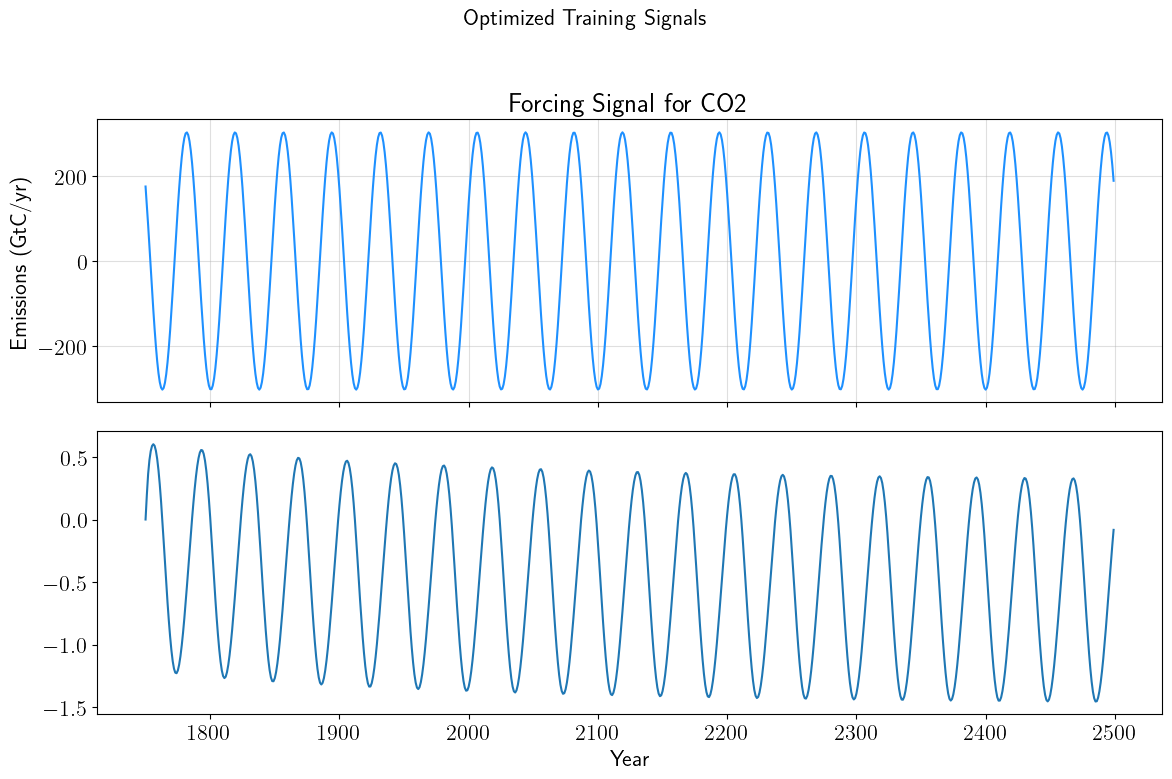

In [18]:
best_params = optimizer.max['params']
plot_optimized_signals(best_params, mean_function_to_run, AGENTS)

In [19]:
def get_detailed_rmse_breakdown(best_params, mean_func, agents, scenarios_valid, series_valid):
    """
    Runs the evaluation one time with the best parameters to get the
    RMSE breakdown for each individual test scenario.
    """
    # 1. Reconstruct the multi-agent emissions dictionary from the best parameters
    uncorrelated_noise = utils_MLP.generate_uncorrelated_signals(n=len(agents), signal_length=n_steps)
    emissions_dict = {}
    for i, agent in enumerate(agents):
        mean_func_params = {
                k.replace('m_param_', ''): v
                for k, v in best_params.items()
                if k.startswith(f'm_param_') and k.endswith(f'_{agent}')
            }
        mean_func_params_clean = {k.replace(f'_{agent}', ''): v for k, v in mean_func_params.items()}

        m_t = mean_func(np.arange(n_steps), **mean_func_params_clean)

        if not CONFIG['USE_WHITE_NOISE'] or CONFIG['CHOSEN_MEAN_FUNCTION'] == 'ornstein_uhlenbeck':
            # OU process has its own noise
            u_t = m_t
        else:
            # Extract this agent's specific parameters from the main params dict
            sigma = best_params[f'sigma_{agent}']
            f_low = best_params[f'f_low_{agent}']
            f_high = best_params[f'f_high_{agent}']

            base_noise = uncorrelated_noise[i]
            nyquist = 0.5 * FS
            b, a = signal.butter(4, [f_low/nyquist, f_high/nyquist], btype='band')
            w_t = signal.filtfilt(b, a, base_noise)
            w_t = (w_t - np.mean(w_t)) / np.std(w_t)

            u_t = m_t + sigma * w_t

        emissions_dict[agent] = u_t

    # 2. Run the full FaIR and MLP evaluation pipeline just once
    f_train = run_fair.build_fair(start, stop)
    run_fair.set_emissions(f_train, years, run_fair.ensure_all_agents(emissions_dict, n_steps))
    f_train.run(progress=False)
    _, _, training_temp, _ = run_fair.run_fair(f_train, years)

    train_scenarios = ["best_run"]
    train_series = [(emissions_dict, training_temp, False)]

    error_dict, yhat_dict = utils_MLP.evaluate_LSTM(train_scenarios, train_series, scenarios_valid, series_valid,
                                                    agents=agents, n_lags=0, lstm_size=16, dense_size=32,
                                                    dropout_rate=0.2, l2_penalty=0.01)

    return error_dict, yhat_dict

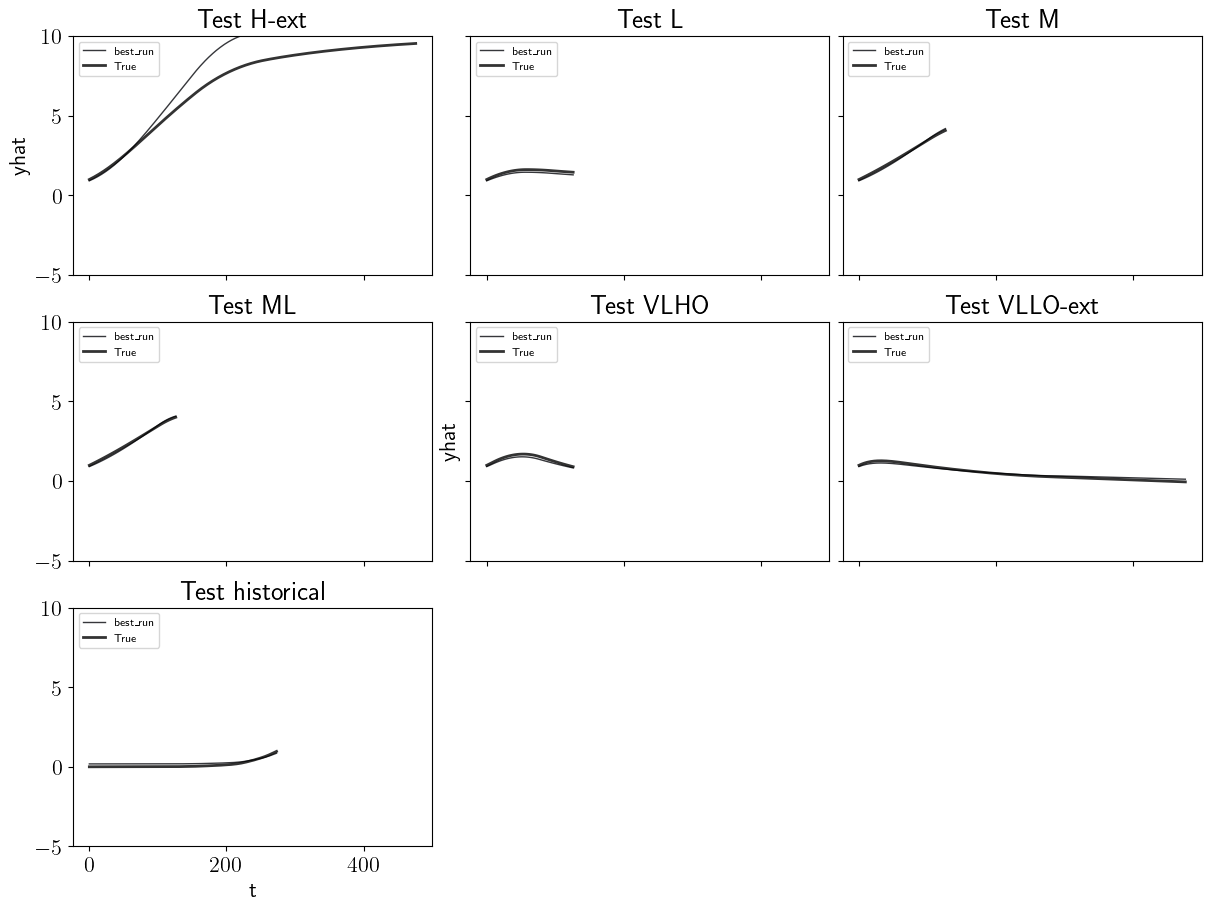

In [22]:
error_dict, yhat_dict = get_detailed_rmse_breakdown(best_params, mean_function_to_run, AGENTS, scenarios_valid, series_valid)
utils_MLP.plot_yhats_grid(error_dict, yhat_dict, delT_dict_valid)

In [23]:
error_dict

{'best_run': {'historical': 0.15123525833269905,
  'H-ext': 1.165747036001486,
  'M': 0.09331928720377614,
  'ML': 0.08957392314889108,
  'L': 0.15339269549940385,
  'VLLO-ext': 0.09895095704436845,
  'VLHO': 0.1435724729021048}}

In [24]:
print(error_dict['best_run'].values())
print(sum(error_dict['best_run'].values()) / len(error_dict['best_run']))

dict_values([0.15123525833269905, 1.165747036001486, 0.09331928720377614, 0.08957392314889108, 0.15339269549940385, 0.09895095704436845, 0.1435724729021048])
0.27082737573324706


dict_values([1.0190096120290721, 9.88866756621618, 6.10995194092845, 3.4106904378384497, 2.0367235632314826, 1.214101548505488])
3.946524111458187


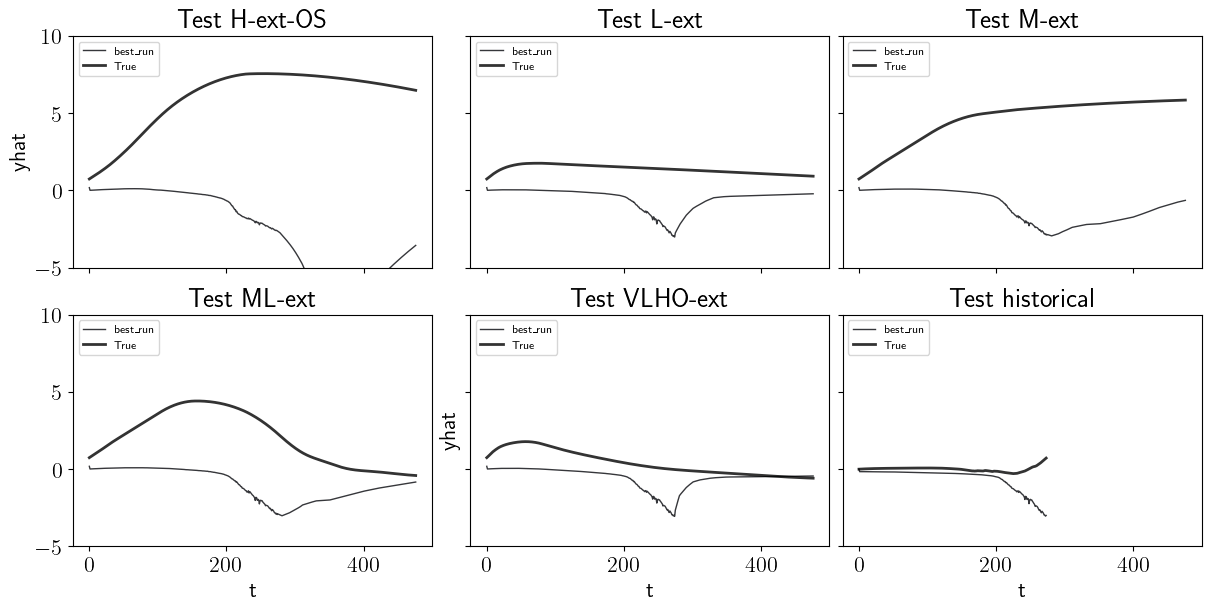

In [22]:
error_dict_tier2, yhat_dict_tier2 = get_detailed_rmse_breakdown(best_params, mean_function_to_run, AGENTS, scenarios_tier2, series_tier2)
utils_MLP.plot_yhats_grid(error_dict_tier2, yhat_dict_tier2, delT_dict_tier2)

print(error_dict_tier2['best_run'].values())
print(sum(error_dict_tier2['best_run'].values()) / len(error_dict_tier2['best_run']))

dict_values([6.183177834899213, 6.543357776403938, 1.6212947253400427, 2.560402183042118, 0.5698530411259964, 3.042338204364318, 2.9030923217190696, 0.6984037531253847, 2.0644334096892845, 0.24698372313171105])
2.6433336972841075


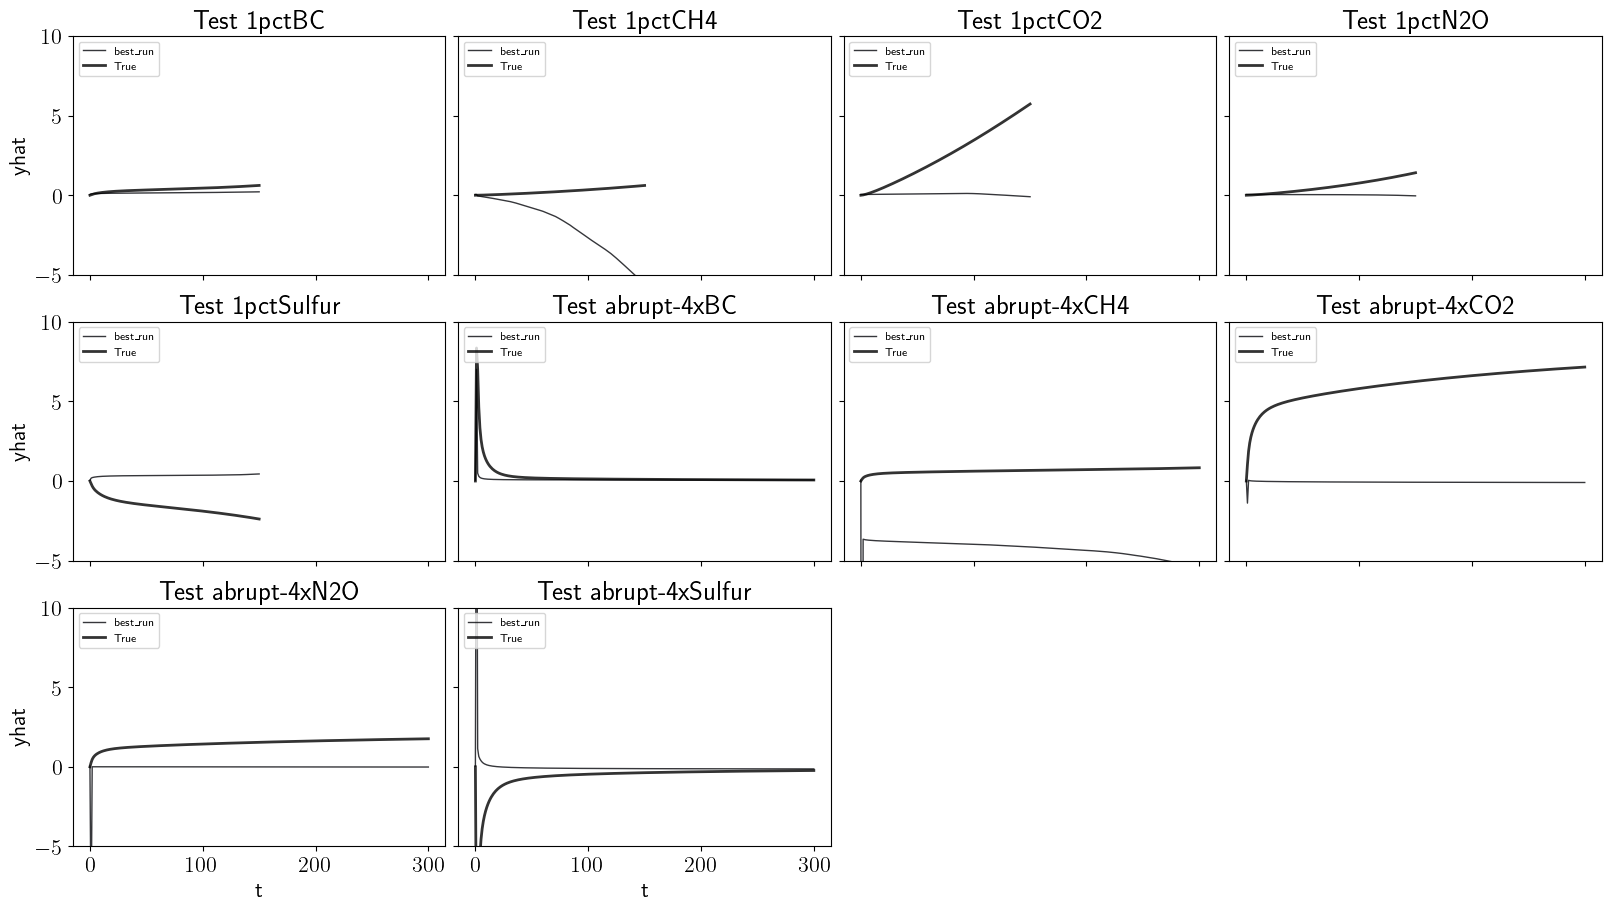

In [23]:
error_dict_DECK, yhat_dict_DECK = get_detailed_rmse_breakdown(best_params, mean_function_to_run, AGENTS, scenarios_DECK, series_DECK)
utils_MLP.plot_yhats_grid(error_dict_DECK, yhat_dict_DECK, delT_dict_DECK)

print(error_dict_DECK['best_run'].values())
print(sum(error_dict_DECK['best_run'].values()) / len(error_dict_DECK['best_run']))

dict_values([0.4248862451477928, 2.4556683492630755, 0.9525392141638239])
1.2776979361915641


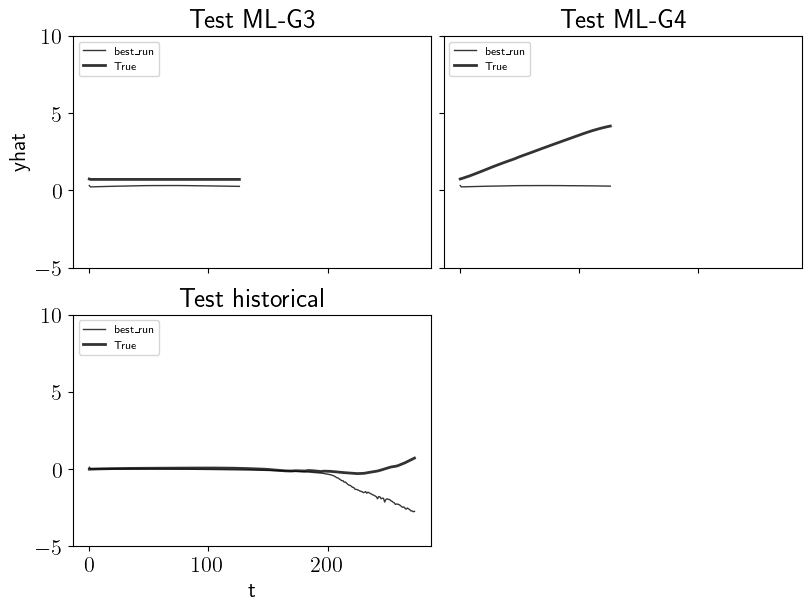

In [24]:
error_dict_geoMIP, yhat_dict_geoMIP = get_detailed_rmse_breakdown(best_params, mean_function_to_run, AGENTS, scenarios_geoMIP, series_geoMIP)
utils_MLP.plot_yhats_grid(error_dict_geoMIP, yhat_dict_geoMIP, delT_dict_geoMIP)

print(error_dict_geoMIP['best_run'].values())
print(sum(error_dict_geoMIP['best_run'].values()) / len(error_dict_geoMIP['best_run']))

dict_values([1.239015316350487, 2.4455461230547626, 0.5674776437257819])
1.4173463610436772


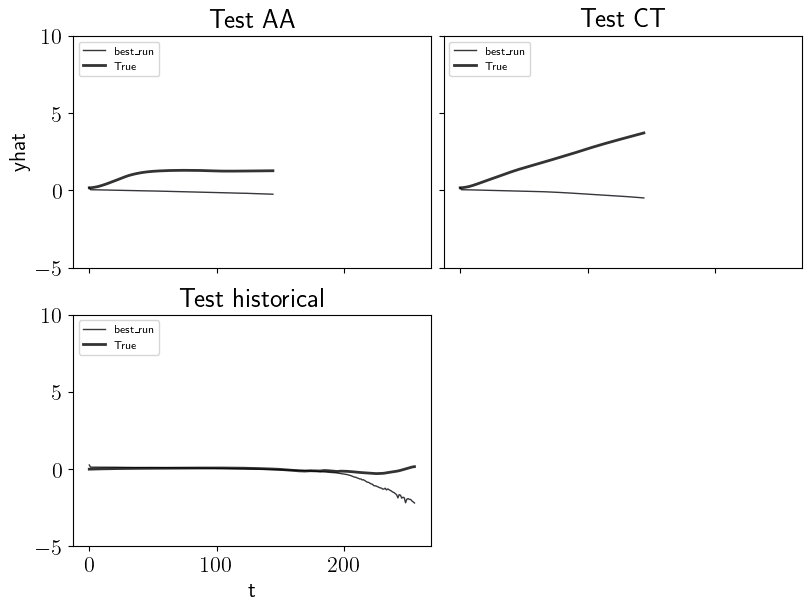

In [25]:
error_dict_CS3, yhat_dict_CS3 = get_detailed_rmse_breakdown(best_params, mean_function_to_run, AGENTS, scenarios_CS3, series_CS3)
utils_MLP.plot_yhats_grid(error_dict_CS3, yhat_dict_CS3, delT_dict_CS3)

print(error_dict_CS3['best_run'].values())
print(sum(error_dict_CS3['best_run'].values()) / len(error_dict_CS3['best_run']))